In [27]:
import numpy as np
import pandas as pd
import cobra
from cobra.io import read_sbml_model
import matplotlib.pyplot as plt
import seaborn as sns
from cobra import Model, Reaction, Metabolite
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import random
from scipy import stats
from scipy.stats import mannwhitneyu, kruskal
from sklearn.preprocessing import normalize, LabelEncoder, MinMaxScaler
from upsetplot import UpSet, from_memberships

In [5]:
#import late exponential CHO model (iCHO2441 with transcriptomics integrated): https://doi.org/10.1002/bit.28982
%store -r constrained_678
model = constrained_678

#### Figure 1c

In [6]:
#generate a dataframe of random objective functions
reaction_ids = []
for r in model.reactions:
    reaction_ids.append(r.id)

growth = model.reactions.get_by_id('biomass_cho_prod')
igg = model.reactions.get_by_id('ICproduct_TRANSLATION_protein')
glucose = model.reactions.get_by_id('EX_glc(e)')
glutamine = model.reactions.get_by_id('EX_gln_L(e)')
ammonia = model.reactions.get_by_id('EX_nh4(e)')
lactate = model.reactions.get_by_id('EX_lac_L(e)')

flux_df = pd.DataFrame()
flux_df['reaction_ids'] = reaction_ids
flux_df = flux_df.set_index('reaction_ids')

labels = ["growth", "igg", "glucose", "glutamine", "ammonia", "lactate"]

for i in range(500):
    coefficients = [random.uniform(-1, 1) for _ in range(6)]
    abs_sum = sum(abs(c) for c in coefficients)
    coefficients = [c / abs_sum for c in coefficients]
    objective_dict = {
        growth: coefficients[0],
        igg: coefficients[1],
        glucose: coefficients[2],
        glutamine: coefficients[3],
        ammonia: coefficients[4],
        lactate: coefficients[5]
    }
    header = "{" + ", ".join(f"{name}:{coeff:.4f}" for name, coeff in zip(labels, coefficients)) + "}"

    with model:
        model.objective = objective_dict
        solution = model.optimize()
        fluxes = solution.fluxes.to_list()

    flux_df[header] = fluxes
flux_df

C:\Users\p04121km\AppData\Local\Temp\ipykernel_23916\3095744792.py:38: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  flux_df[header] = fluxes
C:\Users\p04121km\AppData\Local\Temp\ipykernel_23916\3095744792.py:38: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  flux_df[header] = fluxes
C:\Users\p04121km\AppData\Local\Temp\ipykernel_23916\3095744792.py:38: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at 

,"{growth:0.0433, igg:-0.2505, glucose:-0.2984, glutamine:0.0815, ammonia:-0.1232, lactate:-0.2031}","{growth:0.1350, igg:0.2331, glucose:-0.2013, glutamine:-0.1465, ammonia:-0.1040, lactate:0.1801}","{growth:-0.2269, igg:-0.1725, glucose:-0.1012, glutamine:0.2144, ammonia:0.2094, lactate:-0.0756}","{growth:0.2373, igg:-0.1619, glucose:-0.2373, glutamine:0.0943, ammonia:0.1277, lactate:0.1416}","{growth:-0.0013, igg:0.1121, glucose:0.1609, glutamine:-0.3489, ammonia:0.0849, lactate:0.2918}","{growth:-0.1980, igg:-0.1942, glucose:-0.2544, glutamine:-0.1046, ammonia:0.0836, lactate:0.1652}","{growth:-0.1744, igg:0.0811, glucose:0.2764, glutamine:-0.0684, ammonia:0.2674, lactate:0.1324}","{growth:-0.1046, igg:-0.1462, glucose:0.1430, glutamine:0.0264, ammonia:0.4909, lactate:-0.0889}","{growth:0.1248, igg:0.1199, glucose:0.2696, glutamine:-0.1880, ammonia:0.2154, lactate:0.0824}","{growth:-0.0752, igg:0.1776, glucose:0.0099, glutamine:-0.2395, ammonia:0.2518, lactate:0.2460}",...,"{growth:-0.1401, igg:-0.1246, glucose:0.1142, glutamine:-0.0118, ammonia:-0.2338, lactate:-0.3754}","{growth:0.1545, igg:0.2432, glucose:-0.2497, glutamine:-0.1715, ammonia:-0.0709, lactate:0.1102}","{growth:-0.1761, igg:0.0244, glucose:0.1627, glutamine:-0.3214, ammonia:0.2295, lactate:-0.0858}","{growth:0.1521, igg:0.2623, glucose:0.2330, glutamine:-0.0759, ammonia:-0.0538, lactate:-0.2228}","{growth:0.0083, igg:-0.3340, glucose:0.3200, glutamine:0.0608, ammonia:-0.0936, lactate:0.1832}","{growth:0.0477, igg:0.1799, glucose:0.3160, glutamine:0.3279, ammonia:0.0268, lactate:0.1017}","{growth:0.0796, igg:-0.0072, glucose:-0.2635, glutamine:0.1900, ammonia:-0.2082, lactate:-0.2516}","{growth:0.1457, igg:0.0006, glucose:0.1906, glutamine:-0.3306, ammonia:0.0761, lactate:0.2565}","{growth:0.2850, igg:0.0631, glucose:0.0672, glutamine:-0.2902, ammonia:0.0164, lactate:0.2781}","{growth:-0.1764, igg:-0.0174, glucose:-0.2623, glutamine:0.1200, ammonia:-0.0316, lactate:-0.3922}"
reaction_ids,,,,,,,,,,,,,,,,,,,,,
10FTHF5GLUtl,0.000000e+00,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0.000000e+00
10FTHF5GLUtm,0.000000e+00,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0.000000e+00
10FTHF6GLUtl,0.000000e+00,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0.000000e+00
10FTHF6GLUtm,0.000000e+00,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0.000000e+00
10FTHF7GLUtl,0.000000e+00,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0.000000e+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
OST_complex,1.709397e-05,0.0,0.000059,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.709397e-05,0.0,0.0,1.709397e-05
Proteasome_degradation,-3.061622e-21,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,3.061622e-21,0.0,0.0,-3.061622e-21
DM_igg[g],0.000000e+00,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0.000000e+00


C:\Users\p04121km\AppData\Local\anaconda3\envs\prosperity_project\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\p04121km\AppData\Local\anaconda3\envs\prosperity_project\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\p04121km\AppData\Local\anaconda3\envs\prosperity_project\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\p041

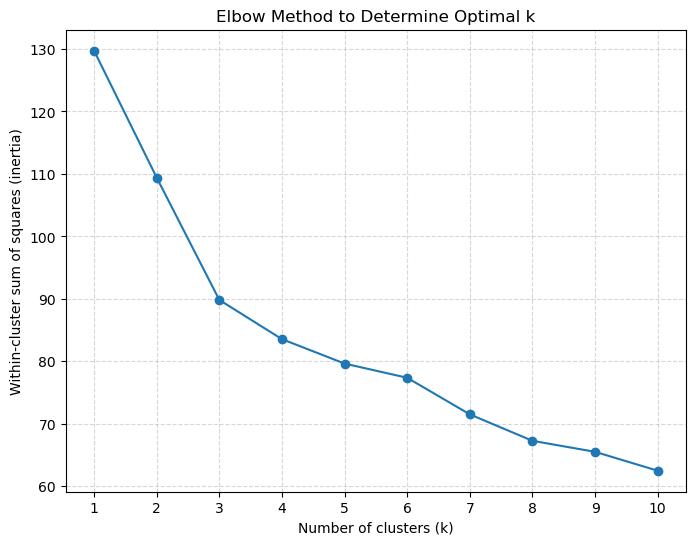

In [7]:
#determine optimal k frequency. (N.B. this will change with each run, so will look different from figure in paper)
inertia = []
k_values = range(1, 11)  # test k=1 to k=10

X = normalize(flux_df.T)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)  # sum of squared distances to cluster centers

# Plot the elbow plot
plt.figure(figsize=(8, 6))
plt.plot(k_values, inertia, marker='o')
plt.xticks(k_values)
plt.xlabel('Number of clusters (k)')
plt.ylabel('Within-cluster sum of squares (inertia)')
plt.title('Elbow Method to Determine Optimal k')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

C:\Users\p04121km\AppData\Local\anaconda3\envs\prosperity_project\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


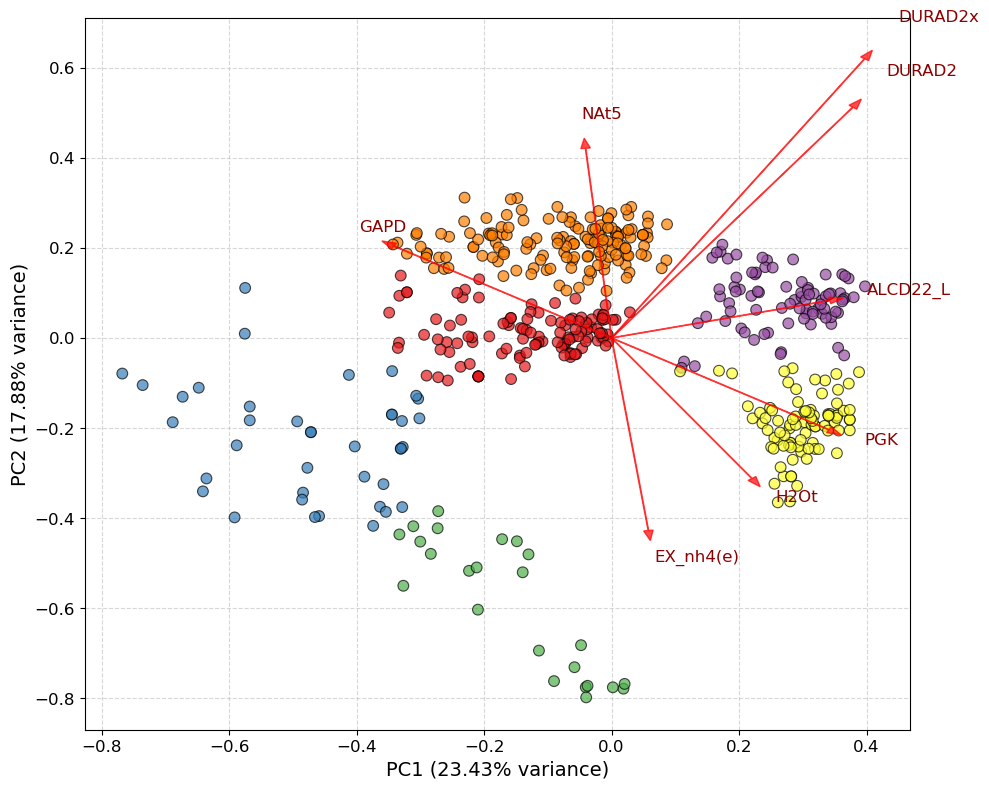

In [8]:
X = normalize(flux_df.T)  # shape: samples × features
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
df_pca = pd.DataFrame(X_pca, index=flux_df.columns, columns=['PC1', 'PC2'])

#here, set k to be whatever was optimal in the elbow plot
kmeans = KMeans(n_clusters=6, random_state=1, n_init='auto')
kmeans.fit(df_pca)
cluster_labels = pd.DataFrame(kmeans.labels_, index=flux_df.columns, columns=['cluster'])
fig, ax = plt.subplots(figsize=(10, 8))

# build PCA plot
sns.scatterplot(
    data=df_pca,
    x='PC1', y='PC2',
    hue=cluster_labels['cluster'],
    palette='Set1',
    s=60,
    alpha=0.7,
    legend=False,
    edgecolor='black',   # outlines around dots
    linewidth=0.8,
    ax=ax
)

loadings = pd.DataFrame(
    pca.components_.T,  # features × PCs
    index=flux_df.index,
    columns=['PC1', 'PC2']
)

top_features = set(
    loadings['PC1'].abs().sort_values(ascending=False).head(5).index
).union(
    loadings['PC2'].abs().sort_values(ascending=False).head(5).index
)

# Plot top feature loadings as arrows
scale = 1.5  # adjust arrow length
for feature in top_features:
    x_loading = loadings.loc[feature, 'PC1'] * scale
    y_loading = loadings.loc[feature, 'PC2'] * scale
    ax.arrow(0, 0, x_loading, y_loading, color='red', alpha=0.7,
             head_width=0.015, length_includes_head=True)
    ax.text(x_loading * 1.1, y_loading * 1.1, feature, color='darkred', fontsize=12)

# Labels and grid
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)", fontsize=14, color='black')
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)", fontsize=14, color='black')
ax.tick_params(axis='both', labelsize=12, colors='black')
ax.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax.set_axisbelow(True)

# Make the outer border (spines) black
for spine in ax.spines.values():
    spine.set_color('black')
    spine.set_linewidth(0.8)

plt.tight_layout()
#plt.savefig('pca_28102025_styled.png', bbox_inches='tight', dpi=300)
plt.show()

In [9]:
#how many solutions fall into each cluster?
print(cluster_labels['cluster'].value_counts())

cluster
4    151
0    114
5     88
3     84
1     39
2     24
Name: count, dtype: int64


In [10]:
#how do the loadings correlate with PC1 and PC2?
pc1_loadings = loadings['PC1'].abs().sort_values(ascending=False).head(5)
pc2_loadings = loadings['PC2'].abs().sort_values(ascending=False).head(5)
print(pc1_loadings)
print(pc2_loadings)

reaction_ids
DURAD2x     0.272770
DURAD2      0.261280
ALCD22_L    0.242601
GAPD        0.240270
PGK         0.240270
Name: PC1, dtype: float64
reaction_ids
DURAD2x      0.425685
DURAD2       0.353430
EX_nh4(e)    0.299775
NAt5         0.295513
H2Ot         0.220189
Name: PC2, dtype: float64


### Figure 1d

In [11]:
#save cluster labels to a file, and reformat so that reactions are headers of columns and the coefficients of these reactions are the values in each column
#cluster_labels.to_csv('cluster_labels_late_6_27102025.csv')
#import reformated file, ready to boxplot the coefficients to find trends with the Kmeans clusters
boxplot = pd.read_csv(r'cluster_labels_late_6_27102025.csv') #file name for reformated file (I have used the file from the data in Figure 1a in paper
boxplot = boxplot.set_index('cluster')

                         p_value
Glucose exchange    1.320061e-47
Lactate exchange    8.131993e-18
Ammonia exchange    3.168000e-12
IgG productivity    9.703391e-02
Growth rate         2.736372e-01
Glutamine exchange  5.165283e-01


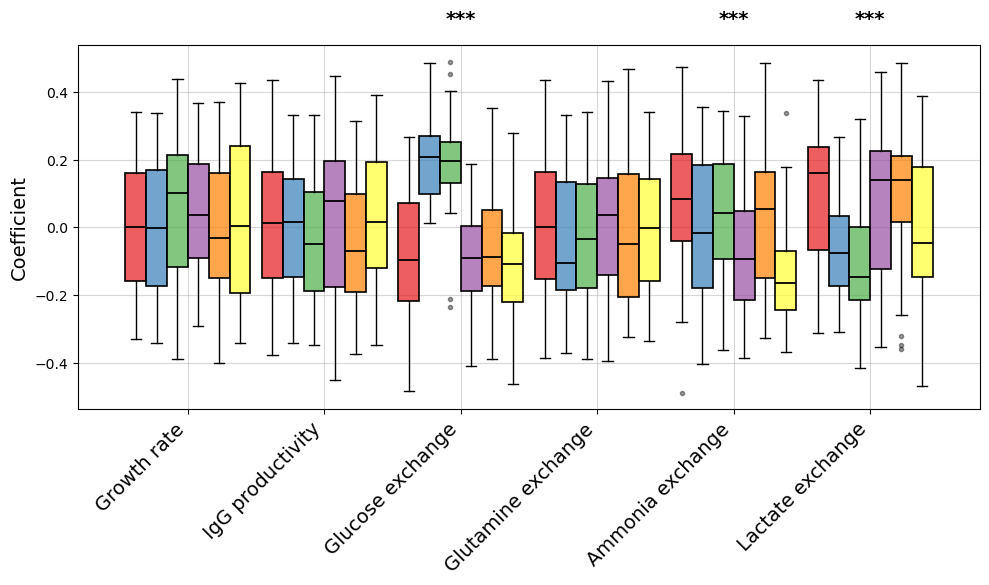

In [12]:
# --- Step 1: Define data and clusters ---
df = boxplot
clusters = sorted(df.index.unique())
reactions = df.columns
width = 0.18  # smaller width for multiple clusters

# --- Step 2: Statistical test (run BEFORE plotting) ---
pvals = {}
for reaction in df.columns:
    groups = [df.loc[c, reaction].dropna() for c in clusters]
    if len(clusters) == 2:
        stat, p = mannwhitneyu(groups[0], groups[1], alternative='two-sided')
    else:
        stat, p = kruskal(*groups)
    pvals[reaction] = p

# Collect p-values into a DataFrame
pvals_df = pd.DataFrame.from_dict(pvals, orient='index', columns=['p_value'])
pvals_df = pvals_df.sort_values('p_value')
print(pvals_df)

# --- Step 3: Plot boxplots ---
palette = sns.color_palette("Set1", n_colors=len(clusters))
colors = {i: (*palette[i], 0.7) for i in clusters}  # add transparency

fig, ax = plt.subplots(figsize=(10, 6))

# Fix spacing between groups
positions = np.arange(len(reactions)) * (len(clusters) * width + 0.1)

for i, cluster in enumerate(clusters):
    cluster_data = df.loc[cluster]
    pos = positions + (i - (len(clusters) - 1) / 2) * width
    ax.boxplot(
        [cluster_data[rxn].dropna() for rxn in reactions],
        positions=pos,
        widths=width,
        patch_artist=True,
        boxprops=dict(facecolor=colors[cluster], color='black', linewidth=1.2),
        medianprops=dict(color='black', linewidth=1.3),
        whiskerprops=dict(color='black'),
        capprops=dict(color='black'),
        flierprops=dict(marker='o', markersize=3, markerfacecolor='black', alpha=0.4)
    )

# --- Step 4: Add significance annotations ---
def significance_label(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return ''

# Calculate Y position for labels
ymax = df.max().max()
y_offset = (df.max().max() - df.min().min()) * 0.1

for i, rxn in enumerate(reactions):
    if rxn not in pvals:
        continue  # skip if missing
    pval = pvals[rxn]
    label = significance_label(pval)
    if label:
        ax.text(
            positions[i],
            ymax + y_offset,
            label,
            ha='center',
            va='bottom',
            fontsize=14,
            color='black',
            fontweight='bold'
        )

# --- Step 5: Formatting ---
ax.set_xticks(positions)
ax.set_xticklabels(reactions, rotation=45, ha='right', fontsize=14)
ax.set_ylabel('Coefficient', fontsize=14)

# Add grid behind plots
ax.grid(True, linestyle='-', alpha=0.5, zorder=0)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_color('black')
    spine.set_linewidth(0.8)

plt.tight_layout()
#plt.savefig('boxplot_6clusters_matchedPCA_28102025.png', bbox_inches='tight', dpi=300)
plt.show()

### Figure 2f

In [ ]:
#define function to perform gene deletion screen, with varying proportions of growth:igg in objective function
def objective_function_ko_scan_2(portion_growth, portion_igg):
    with model:
        # 1. Set the objective function
        model.objective = {
            model.reactions.get_by_id('biomass_cho_prod'): portion_growth,
            model.reactions.get_by_id('ICproduct_TRANSLATION_protein'): portion_igg
        }

        # 2. Run baseline optimization
        solution = model.optimize()
        base_growth = solution.fluxes['biomass_cho_prod']
        base_production = solution.fluxes['ICproduct_TRANSLATION_protein']

        # 3. Perform gene knockouts manually
        genes = []
        growth_after = []
        igg_after = []

        for gene in model.genes:
            with model:
                gene.knock_out()
                sol = model.optimize()
                genes.append(gene.id)
                growth_after.append(sol.fluxes.get('biomass_cho_prod', 0))
                igg_after.append(sol.fluxes.get('ICproduct_TRANSLATION_protein', 0))

        knockout_df = pd.DataFrame({
            'gene': genes,
            'growth_after_ko': growth_after,
            'igg_after_ko': igg_after
        })

        # 4. Classify each knockout
        reduce_growth_only = []
        reduce_igg_only = []
        reduce_both = []
        no_effect = []

        for _, row in knockout_df.iterrows():
            gene = row['gene']
            growth = row['growth_after_ko']
            igg = row['igg_after_ko']
            growth_ok = growth >= base_growth * 0.99
            igg_ok = igg >= base_production * 0.99

            if not growth_ok and igg_ok:
                reduce_growth_only.append(gene)
            elif growth_ok and not igg_ok:
                reduce_igg_only.append(gene)
            elif not growth_ok and not igg_ok:
                reduce_both.append(gene)
            elif growth_ok and igg_ok:
                no_effect.append(gene)

        total_genes = len(model.genes)

        proportion_which_reduce_growth_only = len(reduce_growth_only) / total_genes
        proportion_which_reduce_igg_only = len(reduce_igg_only) / total_genes
        proportion_which_reduce_both = len(reduce_both) / total_genes
        proportion_no_effect = len(no_effect) / total_genes

        overall_fluxes = solution.fluxes.to_list()

        return (
            proportion_which_reduce_growth_only,
            proportion_which_reduce_igg_only,
            proportion_which_reduce_both,
            proportion_no_effect,
            knockout_df,
            overall_fluxes
        )

In [ ]:
#generate results for 100% biomass maximisation, 50:50 growth:igg maximisation and 100% igg maximisation
growth_maximisation = objective_function_ko_scan_2(1,0)
split_optimisation = objective_function_ko_scan_2(0.5,0.5)
igg_maximisation = objective_function_ko_scan_2(0,1)

In [13]:
#import above results as generate in another notebook
%store -r growth_maximisation
%store -r split_optimisation
%store -r igg_maximisation

In [14]:
#generate an overall df with all gene deletion results in
overall_df = growth_maximisation[4]
overall_df['growth_after_ko_split_obj'] = split_optimisation[4]['growth_after_ko'].to_list()
overall_df['igg_after_ko_split_obj'] = split_optimisation[4]['igg_after_ko'].to_list()
overall_df['growth_after_ko_igg_obj'] = igg_maximisation[4]['growth_after_ko'].to_list()
overall_df['igg_after_ko_igg_obj'] = igg_maximisation[4]['igg_after_ko'].to_list()
overall_df = overall_df.set_index('gene')
#overall_df.to_csv('objective_functions_ko_scan.csv')

In [21]:
# --- Helper: round to n significant figures ---
def round_to_n_sig_figs(x, n=4):
    """Round a number to n significant figures"""
    if x == 0 or pd.isna(x):
        return x
    return round(x, -int(np.floor(np.log10(abs(x)))) + (n - 1))


# --- Step 1: Round the original dataframe ---
data = overall_df.applymap(lambda x: round_to_n_sig_figs(x, 4))

# --- Step 2: Calculate modes for each column ---
column_modes = {}
for col in data.columns:
    mode_result = stats.mode(data[col], keepdims=True)
    column_modes[col] = mode_result.mode[0]

# --- Step 3: Create comparison dataframe (categorical) ---
comparison_df = pd.DataFrame(index=data.index, columns=data.columns)

for col in data.columns:
    mode_val = column_modes[col]
    for row in data.index:
        value = data.loc[row, col]
        if pd.isna(value):
            comparison_df.loc[row, col] = np.nan
        elif value < 0.99 * mode_val:
            comparison_df.loc[row, col] = 'decreased'
        elif 0.99 * mode_val <= value <= mode_val:
            comparison_df.loc[row, col] = 'same'
        else:
            comparison_df.loc[row, col] = 'increased'

# --- Step 4: Remove rows where all values are 'same' ---
rows_to_keep = (comparison_df != 'same').any(axis=1)
filtered_data = data[rows_to_keep].copy()            # numerical version
filtered_comparison = comparison_df[rows_to_keep].copy()  # categorical version

print(f"Removed {(~rows_to_keep).sum()} rows where all values matched their column modes")
print(f"Remaining rows: {len(filtered_comparison)}")

# --- Step 5: Save both dataframes ---
#filtered_data.to_csv("overall_df_filtered_30102025.csv", index=True)
#filtered_comparison.to_csv("comparison_df_categorical_30102025.csv", index=True)

print("✅ Saved:")
print("  • 'overall_df_filtered.csv' — numeric values with unchanged rows removed")
print("  • 'comparison_df_categorical.csv' — categorical increase/decrease/same table")

# --- Optional: Summary table ---
summary = filtered_comparison.apply(lambda x: x.value_counts()).fillna(0).astype(int)
summary = summary[(summary != 0).any(axis=1)]
print("\nSummary per column:")
print(summary)

C:\Users\p04121km\AppData\Local\Temp\ipykernel_23916\1230491734.py:10: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  data = overall_df.applymap(lambda x: round_to_n_sig_figs(x, 4))


Removed 1809 rows where all values matched their column modes
Remaining rows: 632
✅ Saved:
  • 'overall_df_filtered.csv' — numeric values with unchanged rows removed
  • 'comparison_df_categorical.csv' — categorical increase/decrease/same table

Summary per column:
           growth_after_ko  igg_after_ko  growth_after_ko_split_obj  \
decreased              142             2                        142   
increased                0           372                          0   
same                   490           258                        490   

           igg_after_ko_split_obj  growth_after_ko_igg_obj  \
decreased                     198                        3   
increased                     139                        0   
same                          295                      629   

           igg_after_ko_igg_obj  
decreased                   150  
increased                     0  
same                        482  


In [ ]:
#save resulting dataframe so despite starting growth/igg across different objectives, a gene is classified as same/decreased/increased target for each objective
#comparison_df.to_csv('categorical_knockout_df.csv')

In [22]:
#define a target as one which at late exponential time point can decrease growth but maintain or increase igg, thereby shifting energy towards igg production
decreased_growth_same_igg_1 = []
decreased_growth_increased_igg_1 = []
decreased_growth_same_igg_2 = []
decreased_growth_increased_igg_2 = []
decreased_growth_same_igg_3 = []
decreased_growth_increased_igg_3 = []

for n in range(len(comparison_df)):
    #growth maximisation
    if comparison_df.iloc[n,0] == 'decreased':
        if comparison_df.iloc[n,1] == 'same':
            decreased_growth_same_igg_1.append(n)
        if comparison_df.iloc[n,1] == 'increased':
            decreased_growth_increased_igg_1.append(n)
    #50:50
    if comparison_df.iloc[n,2] == 'decreased':
        if comparison_df.iloc[n,3] == 'same':
            decreased_growth_same_igg_2.append(n)
        if comparison_df.iloc[n,3] == 'increased':
            decreased_growth_increased_igg_2.append(n)
    #igg maximisation
    if comparison_df.iloc[n,4] == 'decreased':
        if comparison_df.iloc[n,5] == 'same':
            decreased_growth_same_igg_3.append(n)
        if comparison_df.iloc[n,5] == 'increased':
            decreased_growth_increased_igg_3.append(n)
print('number of targets that maintain IgG in growth maximisation obj:',len(decreased_growth_same_igg_1))
print('number of targets that increase IgG in growth maximisation obj:',len(decreased_growth_increased_igg_1))
print('number of targets that maintain IgG in 50:50 obj:',len(decreased_growth_same_igg_2))
print('number of targets that increase IgG in 50:50 obj:',len(decreased_growth_increased_igg_2))
print('number of targets that maintain IgG in IgG maximisation obj:',len(decreased_growth_same_igg_3))
print('number of targets that increase IgG in IgG maximisation obj:',len(decreased_growth_increased_igg_3))

number of targets that maintain IgG in growth maximisation obj: 63
number of targets that increase IgG in growth maximisation obj: 77
number of targets that maintain IgG in 50:50 obj: 0
number of targets that increase IgG in 50:50 obj: 139
number of targets that maintain IgG in IgG maximisation obj: 0
number of targets that increase IgG in IgG maximisation obj: 0


In [23]:
#convert the gene ids of targets into gene names, for interpretation
#here I will import a conversion file I made for another project, but append some more converted ids that are relevant here
#converted using Biomart tool: https://www.ensembl.org/biomart/martview/2744b6c3a4a58e18f971aeacd25426dc
df = pd.read_csv(r'gene_ids.csv')
gene_dict = dict(zip(df['WikiGene ID'], df['Gene name']))
gene_dict[100760867] = 'Tent4a'
gene_dict[100774671] = 'Pole'
gene_dict[100753174] = 'Rfc5'
gene_dict[100764158] = 'Polq'
gene_dict[100751096] = 'Poll'
gene_dict[100761682] = 'Pold4'
gene_dict[100769107] = 'Poln'
gene_dict[103163165] = 'LOC103163165'
gene_dict[100753811] = 'Polr3a'
gene_dict[100754072] = 'Polr2g'
gene_dict[100767957] = 'Polr1a'
gene_dict[100760363] = 'Papolb'
gene_dict[100767495] = 'Tut7'
gene_dict[100762645] = 'Polr2k'
gene_dict[100759490] = 'LOC100759490'
gene_dict[100689016] = 'Polr2a'
gene_dict[100753545] = 'Eef1g'
gene_dict[100751998] = 'Eif3h'
gene_dict[100753124] = 'Acacb'
gene_dict[100766362] = 'Tm7sf2'
gene_dict[103159960] = 'LOC103159960'
gene_dict[100763640] = 'Ptpmt1'
gene_dict[100767338] = 'Tpi1'
gene_dict[100764360] = 'Lars1'
gene_dict[100773768] = 'Eif4e'
gene_dict[100689051] = 'Eef2'
gene_dict[100752954] = 'Eif4ebp3'
gene_dict[100766778] = 'Eif4e1b'
gene_dict[100755894] = 'Eef1d'
gene_dict[100760982] = 'Papola'
gene_dict[100759832] = 'LOC100759832'

In [24]:
#build some functions to convert gene ids from target lists
genes = comparison_df.index.to_list()

def indices_to_genes(indices, genes):
    """Convert index positions to gene IDs."""
    return [genes[n] for n in indices]


def convert_gene_ids(gene_list, gene_dict):
    """Convert gene IDs using gene_dict, with error handling."""
    converted = []
    for g in gene_list:
        try:
            g_int = int(g)
            if g_int in gene_dict:
                converted.append(gene_dict[g_int])
            else:
                print(f"ID not found in dictionary: {g}")
                converted.append(g)
        except ValueError:
            print(f"Invalid ID (not an integer): {g}")
            converted.append(g)
    return converted

increased_igg_1 = indices_to_genes(decreased_growth_increased_igg_1, genes)
maintain_igg_1  = indices_to_genes(decreased_growth_same_igg_1, genes)
increased_igg_2 = indices_to_genes(decreased_growth_increased_igg_2, genes)

increased_igg_1_converted = convert_gene_ids(increased_igg_1, gene_dict)
maintain_igg_1_converted  = convert_gene_ids(maintain_igg_1, gene_dict)
increased_igg_2_converted = convert_gene_ids(increased_igg_2, gene_dict)

C:\Users\p04121km\AppData\Local\anaconda3\envs\prosperity_project\Lib\site-packages\upsetplot\data.py:303: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
C:\Users\p04121km\AppData\Local\anaconda3\envs\prosperity_project\Lib\site-packages\upsetplot\plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace

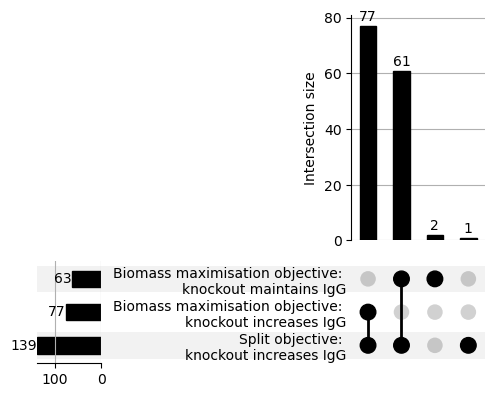

In [28]:
#make an upset plot to visualise the intersection of these sets of targets
sets = {
    "Biomass maximisation objective: \nknockout maintains IgG": set(maintain_igg_1_converted),
    "Biomass maximisation objective: \nknockout increases IgG": set(increased_igg_1_converted),
    "Split objective: \nknockout increases IgG": set(increased_igg_2_converted)
}

# --- Create combinations (memberships) ---
memberships = []
for element in set.union(*sets.values()):  # all unique elements
    membership = [name for name, s in sets.items() if element in s]
    memberships.append(membership)

# --- Convert to a format usable by UpSetPlot ---
data = from_memberships(memberships)

# --- Create and plot the UpSet diagram ---
upset = UpSet(
    data,
    subset_size='count',
    show_counts=True,
    sort_by='cardinality'
)
upset.plot()
plt.subplots_adjust(bottom=0.01)
#plt.savefig('intersection_of_potential_targets.png',bbox_inches='tight',dpi=300)
plt.show()